In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from utils.plots import calculate_accuracy, plot_confusion_matrices, plot_distributions, plot_accuracy, plot_metric_heatmap, plot_precision_recall_curves, plot_cooccurrence, plot_error_distribution, GT_COLS, PRED_COLS, LABELS

0 shot
{'theme_accuracy': np.float64(0.8728971962616823), 'topic_accuracy': np.float64(0.8990654205607477), 'concept_accuracy': np.float64(0.7476635514018691), 'total_accuracy': np.float64(0.6056074766355141)}
random 1 shot
{'theme_accuracy': np.float64(0.7588785046728972), 'topic_accuracy': np.float64(0.7869158878504673), 'concept_accuracy': np.float64(0.7457943925233644), 'total_accuracy': np.float64(0.5364485981308411)}
random 5 shot
{'theme_accuracy': np.float64(0.8934579439252337), 'topic_accuracy': np.float64(0.8953271028037383), 'concept_accuracy': np.float64(0.6747663551401869), 'total_accuracy': np.float64(0.5682242990654206)}
fixed demos
{'theme_accuracy': np.float64(0.8979206049149339), 'topic_accuracy': np.float64(0.9206049149338374), 'concept_accuracy': np.float64(0.6748582230623819), 'total_accuracy': np.float64(0.5954631379962193)}


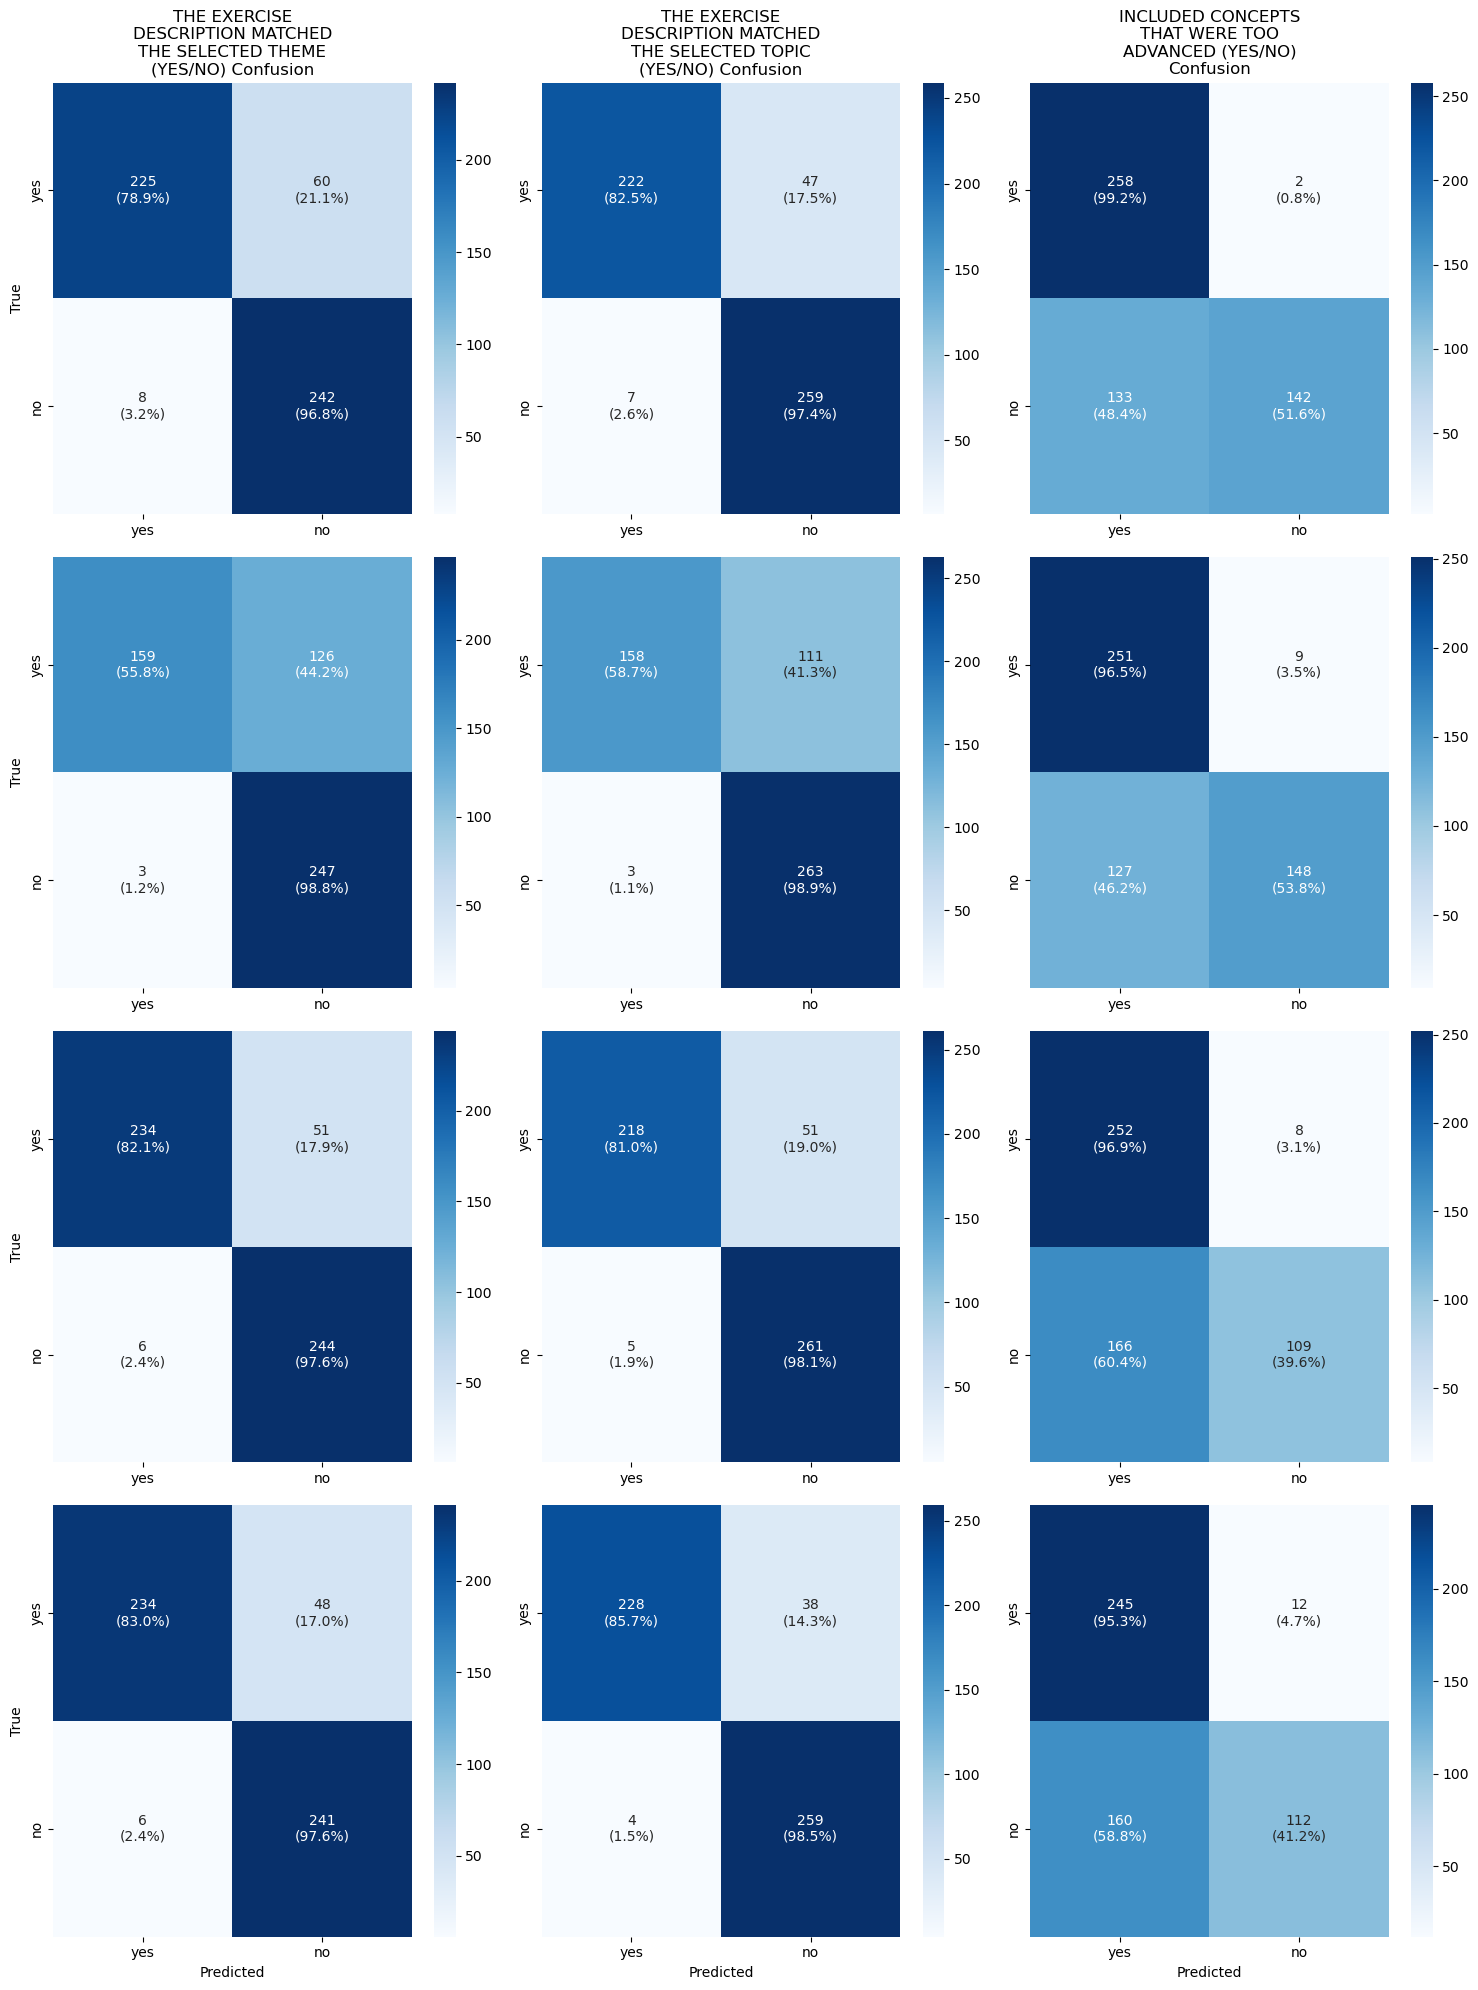

In [3]:
# With concept guardrails in system prompt and list of allowed concepts in user prompt
csvs = [
    ("./outputs/Qwen/Qwen2.5-14B-Instruct/results/batch_16823044_result.csv", "0 shot"),
    ("./outputs/Qwen/Qwen2.5-14B-Instruct/results/batch_16823045_result.csv", "random 1 shot"),
    ("./outputs/Qwen/Qwen2.5-14B-Instruct/results/batch_16823049_result.csv", "random 5 shot"),
    ("./outputs/Qwen/Qwen2.5-14B-Instruct/results/batch_16823050_result.csv", "fixed demos"),
]

"""
1) several runs (effect of random seed)
2) model family (qwen vs llama)
3) model size (large vs small)
4) presence of instructions and number of demonstrations (zero shot with instructions, 1 shot with instructions, 1 shot no instructions, 6 shot with instructions, 6 shot no instructions)
5) type of demonstrations (only positive, mixed, only negative) -- mixed only for 6 shot
"""

fig, axes = plt.subplots(len(csvs), 3, figsize=(15, 5 * len(csvs)))
if len(csvs) == 1:
    axes = [axes]

for i, ((path, note), ax) in enumerate(zip(csvs, axes)):
    print(note)
    df = pd.read_csv(path, sep=";")
    plot_confusion_matrices(df, ax, use_title=True if i == 0 else False, xlabel="Predicted" if i == (len(csvs) - 1) else "", ylabel="True")
    print(calculate_accuracy(df))
    
fig.tight_layout()
plt.show()

0 shot


FileNotFoundError: [Errno 2] No such file or directory: './outputs/results/batch_16817945_result.csv'

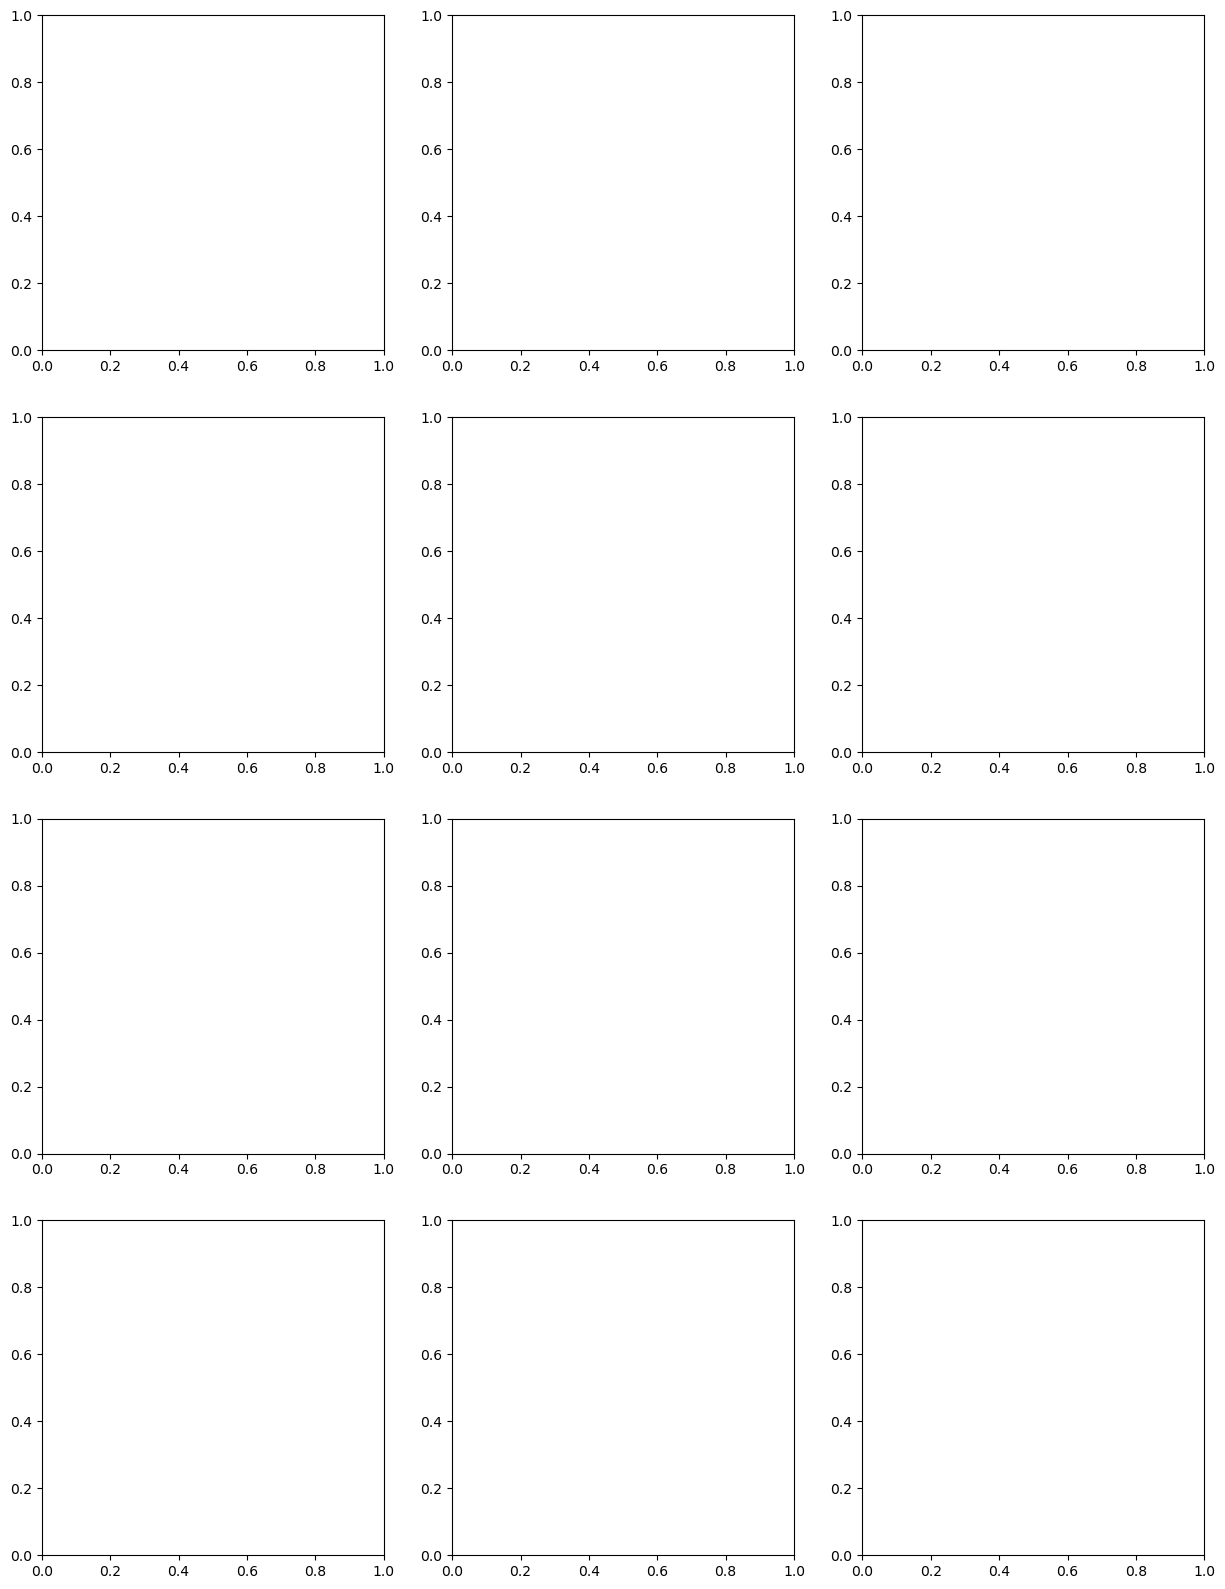

In [4]:
# Without concept guardrails in system prompt and with list of allowed concepts in user prompt
csvs = [
    ("./outputs/results/batch_16817945_result.csv", "0 shot"),
    ("./outputs/results/batch_16817946_result.csv", "random 1 shot"),
    ("./outputs/results/batch_16817947_result.csv", "random 5 shot"),
    ("./outputs/results/batch_16817948_result.csv", "fixed demos"),
]

fig, axes = plt.subplots(len(csvs), 3, figsize=(15, 20))

for (path, note), ax in zip(csvs, axes):
    print(note)
    df = pd.read_csv(path, sep=";")
    plot_confusion_matrices(df, ax)
    print(calculate_accuracy(df))
    
fig.tight_layout()
plt.show()

In [ ]:
# With concept guardrails in system prompt and list of allowed concepts in user prompt, generated with Qwen-72B
csvs = [
    ("./outputs/results/batch_16824074_result.csv", "0 shot"),
]

fig, axes = plt.subplots(len(csvs), 3, figsize=(15, 5 * len(csvs)))
if len(csvs) == 1:
    axes = [axes]

for i, ((path, note), ax) in enumerate(zip(csvs, axes)):
    print(note)
    df = pd.read_csv(path, sep=";")
    plot_confusion_matrices(df, ax, use_title=True if i == 0 else False, xlabel="Predicted" if i == (len(csvs) - 1) else "", ylabel="True")
    print(calculate_accuracy(df))
    
fig.tight_layout()
plt.show()

In [ ]:
def build_figure_for_csv(csvs,
                         labels=LABELS,
                         cols1=GT_COLS,
                         cols2=PRED_COLS,
                         conf=True, acc=True, dist=True):

    filepath, model = csvs
    
    df = pd.read_csv(filepath, sep=";")

    # Layout:
    # Row 0: confusion matrices (3 plots)
    # Row 1: accuracy (1 plot spanning all columns)
    # Row 2-4: distributions (3 rows x 2 columns)

    num_rows = 0
    if conf:
        num_rows += 1
    if acc:
        num_rows += 1
    if dist:
        num_rows += 3

    fig = plt.figure(figsize=(16, num_rows * 6))
    gs = fig.add_gridspec(num_rows, 3)

    # --- Confusion matrices ---
    if conf:
        cm_axes = [
            fig.add_subplot(gs[0, i]) for i in range(3)
        ]
        plot_confusion_matrices(df, cm_axes, labels, cols1, cols2)

    # --- Accuracy (span full width) ---
    if acc:
        acc_ax = fig.add_subplot(gs[1 if conf else 0, :])
        plot_accuracy(df, acc_ax, cols1, cols2)

    # --- Distributions ---
    if dist:
        dist_axes = [
            [fig.add_subplot(gs[num_rows - 3 + i, 0]),
             fig.add_subplot(gs[num_rows - 3 + i, 1])]
            for i in range(len(cols1))
        ]
    
        plot_distributions(df,
                           pd.DataFrame(dist_axes).values,
                           labels,
                           cols1, cols2)

    fig.suptitle(model, fontsize=16)
    fig.tight_layout()

    return fig


def run_on_csvs(csv_paths, conf=True, acc=True, dist=True):
    figs = []

    for path in csv_paths:
        fig = build_figure_for_csv(path, conf=conf, acc=acc, dist=dist)
        figs.append(fig)

    return figs

#run_on_csvs(csvs, acc=False, dist=False)